# Machine Intelligence 2 - Exercise 1: Principal Component Analysis


# Exercise H1.1: PCA: 2-dimensional Toy Data


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## H1.1a


In [2]:
# load data (difference to lecture: rows are samples, cols are features)
pca_2d = np.loadtxt("pca-data-2d.dat")
print(pca_2d.shape)
print(pca_2d)

(10, 2)
[[ 2.4 -2.5]
 [ 0.7 -0.5]
 [ 2.9 -2.2]
 [ 2.2 -1.9]
 [ 3.  -3.1]
 [ 2.7 -2.3]
 [ 1.6 -2. ]
 [ 1.1 -1. ]
 [ 1.6 -1.5]
 [ 0.9 -1.1]]


In [3]:
# calculate mean for each feature separately
mean = np.mean(pca_2d, axis=0)
print(mean)

[ 1.91 -1.81]


In [4]:
# center data (mean = 0 for all features) -> data cloud moves towards origin of the coordinate system
pca_2d_centered = pca_2d - mean
print(pca_2d_centered.shape)
print(pca_2d_centered)

(10, 2)
[[ 0.49 -0.69]
 [-1.21  1.31]
 [ 0.99 -0.39]
 [ 0.29 -0.09]
 [ 1.09 -1.29]
 [ 0.79 -0.49]
 [-0.31 -0.19]
 [-0.81  0.81]
 [-0.31  0.31]
 [-1.01  0.71]]


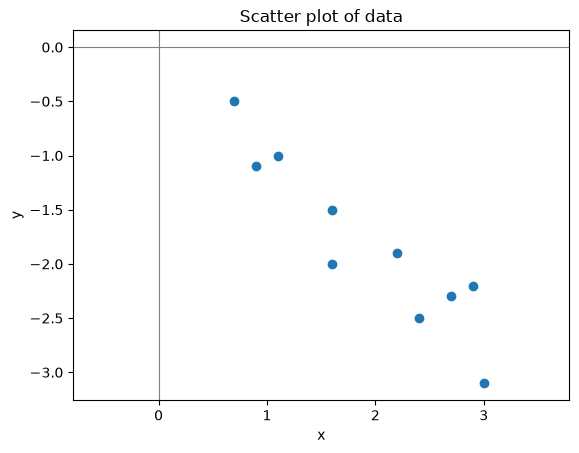

In [5]:
# plot data before centering
plt.scatter(pca_2d[:, 0], pca_2d[:, 1])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of data")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.axis("equal")
plt.show()

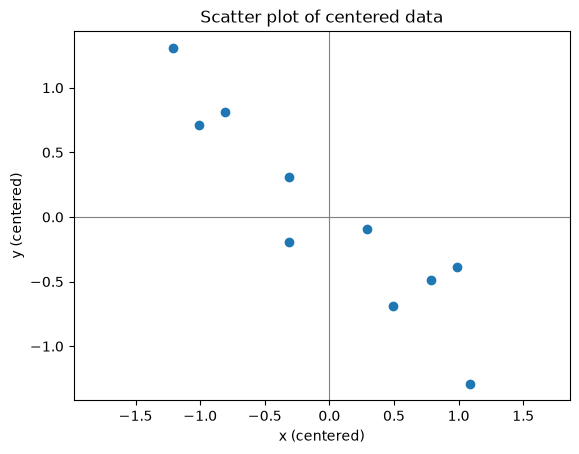

In [6]:
# plot data after centering
plt.scatter(pca_2d_centered[:, 0], pca_2d_centered[:, 1])
plt.xlabel("x (centered)")
plt.ylabel("y (centered)")
plt.title("Scatter plot of centered data")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.axis("equal")
plt.show()

## H1.1b


In [7]:
# compute covariance matrix
C = np.cov(pca_2d_centered, rowvar=False)  # set cols as features
print(C)  # Cov(x,y) and Cov (x,y) are the same as the covariance matrix is symmetric

[[ 0.71655556 -0.61544444]
 [-0.61544444  0.61655556]]


In [8]:
# compute eigenvalues and eigenvectors
# eigenvectors = principal components
# eigenvalues = amount of variance in direction of principal components
eigenvalues, eigenvectors = np.linalg.eig(C)

print("Eigenvalues:")
print(eigenvalues)

print("")

print("Eigenvectors:")
print(eigenvectors)  # eigenvectors are stored as cols

Eigenvalues:
[1.28402771+0.j 0.0490834 +0.j]

Eigenvectors:
[[ 0.73517866+0.j  0.6778734 +0.j]
 [-0.6778734 +0.j  0.73517866+0.j]]


In [9]:
# sort eigenvalues and eigenvectors in descending order (highest to lowest)
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]  # leave rows unattached, just change cols

pcs = eigenvectors
print(pcs)

[[ 0.73517866+0.j  0.6778734 +0.j]
 [-0.6778734 +0.j  0.73517866+0.j]]


In [10]:
# transform data into new PC basis (project data onto PCs)
print(pca_2d_centered.shape)
print(pcs.shape)

pca_2d_pc_coords = pca_2d_centered @ pcs
print(pca_2d_pc_coords)

(10, 2)
(2, 2)
[[ 0.82797019+0.j -0.17511531+0.j]
 [-1.77758033+0.j  0.14285723+0.j]
 [ 0.99219749+0.j  0.38437499+0.j]
 [ 0.27421042+0.j  0.13041721+0.j]
 [ 1.67580142+0.j -0.20949846+0.j]
 [ 0.9129491 +0.j  0.17528244+0.j]
 [-0.09910944+0.j -0.3498247 +0.j]
 [-1.14457216+0.j  0.04641726+0.j]
 [-0.43804614+0.j  0.01776463+0.j]
 [-1.22382056+0.j -0.16267529+0.j]]


/Users/moritzeckardt/Desktop/Code/001_TU_Berlin/Machine_Intelligence_2/.pixi/envs/default/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/moritzeckardt/Desktop/Code/001_TU_Berlin/Machine_Intelligence_2/.pixi/envs/default/lib/python3.12/site-packages/matplotlib/collections.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


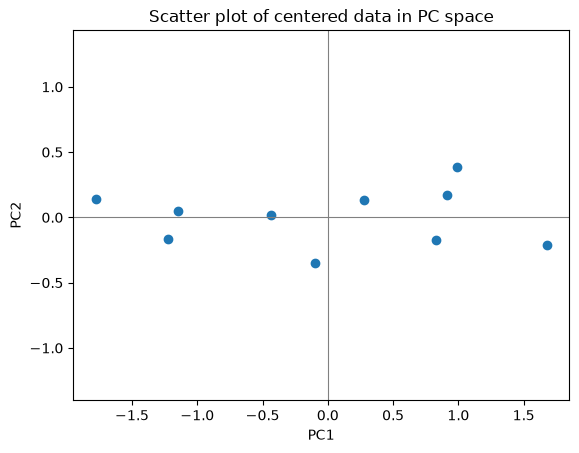

In [11]:
# plot data in new PC basis
plt.scatter(pca_2d_pc_coords[:, 0], pca_2d_pc_coords[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scatter plot of centered data in PC space")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.axis("equal")
plt.show()

## H1.1c


In [12]:
# select only pc1 coordinates
pc1_coords = pca_2d_pc_coords[:, 0:1]
print(pc1_coords.shape)
print(pc1_coords)

(10, 1)
[[ 0.82797019+0.j]
 [-1.77758033+0.j]
 [ 0.99219749+0.j]
 [ 0.27421042+0.j]
 [ 1.67580142+0.j]
 [ 0.9129491 +0.j]
 [-0.09910944+0.j]
 [-1.14457216+0.j]
 [-0.43804614+0.j]
 [-1.22382056+0.j]]


In [13]:
# select pc1
pc1 = pcs[:, 0:1]
print(pc1.shape)
print(pc1)

(2, 1)
[[ 0.73517866+0.j]
 [-0.6778734 +0.j]]


In [14]:
# reconstruct data points in original feature space via matrix mul
pca_2d_centered_reconstructed_pc1 = pc1_coords @ pc1.T
print(pca_2d_centered_reconstructed_pc1)

[[ 0.60870601+0.j -0.56125896+0.j]
 [-1.30683911+0.j  1.20497442+0.j]
 [ 0.72944242+0.j -0.67258429+0.j]
 [ 0.20159364+0.j -0.18587995+0.j]
 [ 1.23201343+0.j -1.1359812 +0.j]
 [ 0.67118069+0.j -0.61886391+0.j]
 [-0.07286314+0.j  0.06718365+0.j]
 [-0.84146502+0.j  0.77587502+0.j]
 [-0.32204217+0.j  0.29693982+0.j]
 [-0.89972675+0.j  0.8295954 +0.j]]


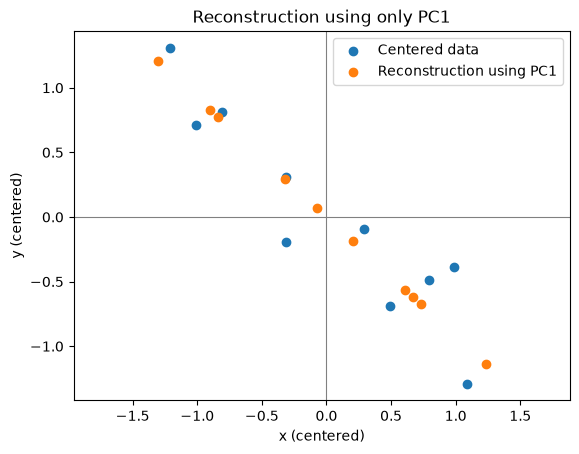

In [15]:
# plot pc1 reconstruction
plt.scatter(pca_2d_centered[:, 0], pca_2d_centered[:, 1], label="Centered data")
plt.scatter(
    pca_2d_centered_reconstructed_pc1[:, 0],
    pca_2d_centered_reconstructed_pc1[:, 1],
    label="Reconstruction using PC1",
)
plt.xlabel("x (centered)")
plt.ylabel("y (centered)")
plt.title("Reconstruction using only PC1")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.axis("equal")
plt.legend()
plt.show()

In [16]:
# select only pc2 coordinates
pc2_coords = pca_2d_pc_coords[:, 1:2]
print(pc2_coords.shape)
print(pc2_coords)

(10, 1)
[[-0.17511531+0.j]
 [ 0.14285723+0.j]
 [ 0.38437499+0.j]
 [ 0.13041721+0.j]
 [-0.20949846+0.j]
 [ 0.17528244+0.j]
 [-0.3498247 +0.j]
 [ 0.04641726+0.j]
 [ 0.01776463+0.j]
 [-0.16267529+0.j]]


In [17]:
# select pc2
pc2 = pcs[:, 1:2]
print(pc2.shape)
print(pc2)

(2, 1)
[[0.6778734 +0.j]
 [0.73517866+0.j]]


In [18]:
# reconstruct data points in original feature space via matrix mul
pca_2d_centered_reconstructed_pc2 = pc2_coords @ pc2.T
print(pca_2d_centered_reconstructed_pc2)

[[-0.11870601+0.j -0.12874104+0.j]
 [ 0.09683911+0.j  0.10502558+0.j]
 [ 0.26055758+0.j  0.28258429+0.j]
 [ 0.08840636+0.j  0.09587995+0.j]
 [-0.14201343+0.j -0.1540188 +0.j]
 [ 0.11881931+0.j  0.12886391+0.j]
 [-0.23713686+0.j -0.25718365+0.j]
 [ 0.03146502+0.j  0.03412498+0.j]
 [ 0.01204217+0.j  0.01306018+0.j]
 [-0.11027325+0.j -0.1195954 +0.j]]


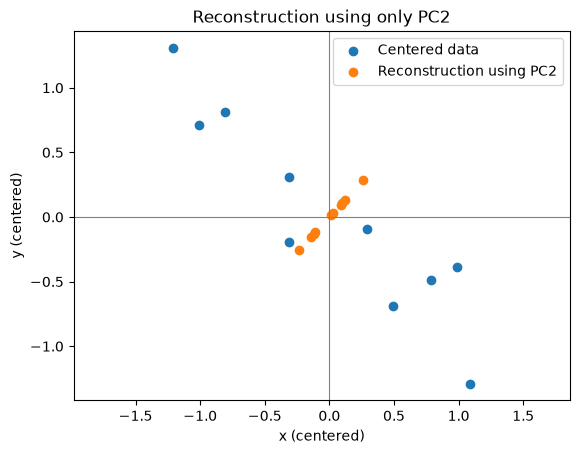

In [19]:
# plot pc2 reconstruction
plt.scatter(pca_2d_centered[:, 0], pca_2d_centered[:, 1], label="Centered data")
plt.scatter(
    pca_2d_centered_reconstructed_pc2[:, 0],
    pca_2d_centered_reconstructed_pc2[:, 1],
    label="Reconstruction using PC2",
)
plt.xlabel("x (centered)")
plt.ylabel("y (centered)")
plt.title("Reconstruction using only PC2")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.axis("equal")
plt.legend()
plt.show()

# Exercise H1.2: PCA: 3-dimensional Toy Data


## H.1.2a


In [20]:
# load data
pca_3d = np.genfromtxt("pca-data-3d.txt", delimiter=",", skip_header=1)
print(pca_3d.shape)
print(pca_3d)

(500, 3)
[[-0.19426329  0.2235241  -0.21112988]
 [ 0.02034613 -0.38014867 -0.99047169]
 [ 0.83225938  3.05490094 -2.72578164]
 ...
 [-1.43283404 -3.48706989  1.83608382]
 [ 0.79887207  1.11430493  2.21229285]
 [ 0.90391051  1.51089626  0.81628342]]


In [21]:
# calculate mean for each feature separately
mean = np.mean(pca_3d, axis=0)
print(mean)  # very small mean already

[ 0.04355465  0.09190794 -0.0594604 ]


In [22]:
# center data
pca_3d_centered = pca_3d - mean
print(pca_3d_centered.shape)
print(pca_3d_centered)

(500, 3)
[[-0.23781794  0.13161615 -0.15166948]
 [-0.02320852 -0.47205661 -0.93101129]
 [ 0.78870474  2.96299299 -2.66632124]
 ...
 [-1.47638869 -3.57897783  1.89554422]
 [ 0.75531742  1.02239699  2.27175325]
 [ 0.86035587  1.41898832  0.87574383]]


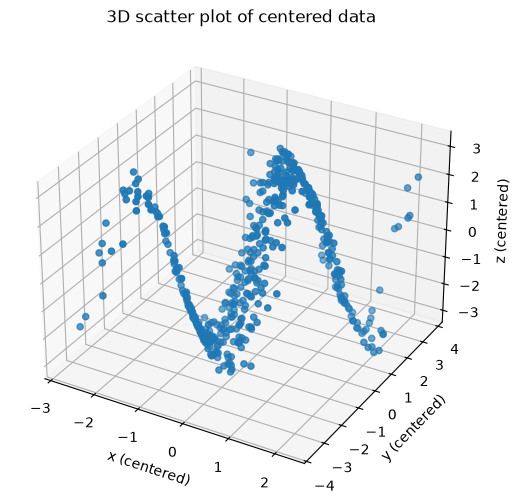

In [23]:
# create scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(pca_3d_centered[:, 0], pca_3d_centered[:, 1], pca_3d_centered[:, 2])

ax.set_xlabel("x (centered)")
ax.set_ylabel("y (centered)")
ax.set_zlabel("z (centered)")
ax.set_title("3D scatter plot of centered data")

plt.show()

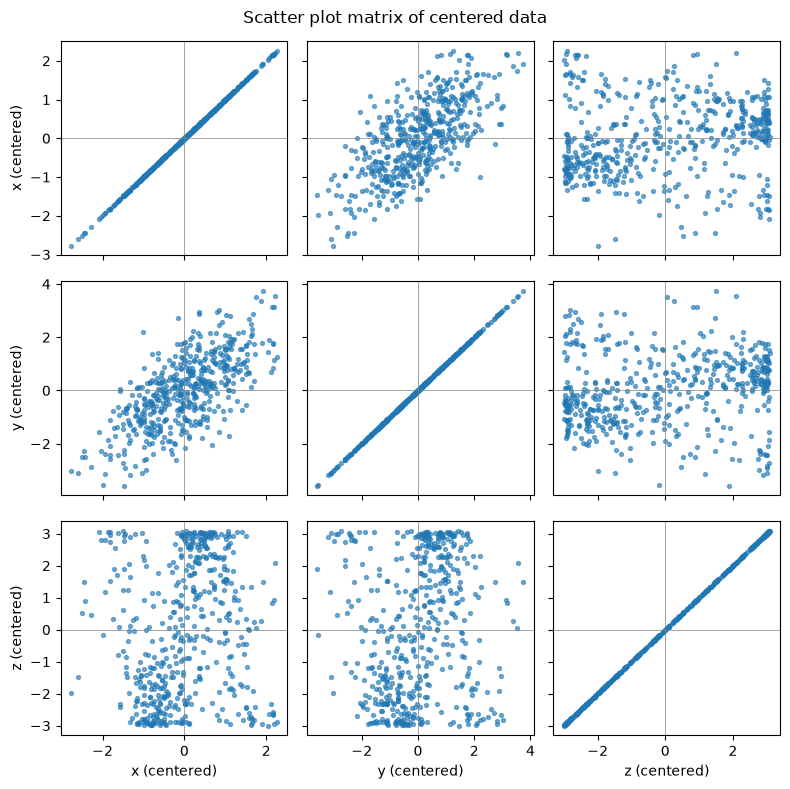

In [24]:
# create scatter plot matrix of centered data
fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex="col", sharey="row")
labels = ["x (centered)", "y (centered)", "z (centered)"]

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.scatter(pca_3d_centered[:, j], pca_3d_centered[:, i], s=8, alpha=0.6)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        if i == 2:
            ax.set_xlabel(labels[j])
        if j == 0:
            ax.set_ylabel(labels[i])

fig.suptitle("Scatter plot matrix of centered data")
plt.tight_layout()
plt.show()

### Findings
- x and y are strongly positively correlated -> their scatter shows a clear upward linear trend
- z has little linear correlation with x or y, but the scatter shows strong nonlinear structure -> z is not independent of them

### Meaning for PCA
- x and y contain redundant information because they are strongly correlated -> PCA will likely combine them into one dominant component roughly along the x–y diagonal
- The perpendicular x–y direction should have relatively little variance -> PCA can compress those two dimensions efficiently
- z contributes different structure -> another principal component will be needed to represent variation involving z
- But PCA only captures linear relationships -> the nonlinear relationship involving z will not be represented especially well by ordinary PCA

## H1.2b


In [25]:
# compute covariance matrix
C_3d = np.cov(pca_3d_centered, rowvar=False)

In [26]:
# compute eigenvalues and eigenvectors
eigenvalues_3d, eigenvectors_3d = np.linalg.eig(C_3d)

In [27]:
print("Eigenvalues:")
print(eigenvalues_3d)

print("")

print("Eigenvectors:")
print(eigenvectors_3d)  # eigenvectors are stored as cols

Eigenvalues:
[0.38503192+0.j 2.24956199+0.j 4.4947884 +0.j]

Eigenvectors:
[[-0.85087048+0.j  0.51120047+0.j  0.12121678+0.j]
 [ 0.52533684+0.j  0.83065188+0.j  0.1844957 +0.j]
 [ 0.00637466+0.j -0.22066159+0.j  0.9753296 +0.j]]


In [28]:
# sort eigenvalues and eigenvectors in descending order (highest to lowest)
# sorting does not affect the direction of the data points after transformation
# but when selecting specific PCs, we might remove a high-variance one
idx = np.argsort(eigenvalues_3d)[::-1]

eigenvalues_3d = eigenvalues_3d[idx]
eigenvectors_3d = eigenvectors_3d[:, idx]  # leave rows unattached, just change cols

pcs_3d = eigenvectors_3d
print(pcs_3d)

[[ 0.12121678+0.j  0.51120047+0.j -0.85087048+0.j]
 [ 0.1844957 +0.j  0.83065188+0.j  0.52533684+0.j]
 [ 0.9753296 +0.j -0.22066159+0.j  0.00637466+0.j]]


In [29]:
# transform data into new basis
print(pca_3d_centered.shape)
print(pcs_3d.shape)

pca_3d_pc_coords = pca_3d_centered @ pcs_3d
print(pca_3d_pc_coords)

(500, 3)
(3, 3)
[[-0.15247264+0.j  0.02122219+0.j  0.27052824+0.j]
 [-0.99794854+0.j -0.19854049+0.j -0.23417617+0.j]
 [-1.95827829+0.j  3.45275661+0.j  0.8684869 +0.j]
 ...
 [ 1.00951126+0.j -4.14588905+0.j -0.6118699 +0.j]
 [ 2.49589319+0.j  0.73408592+0.j -0.09109285+0.j]
 [ 1.2202257 +0.j  1.42525661+0.j  0.018978  +0.j]]


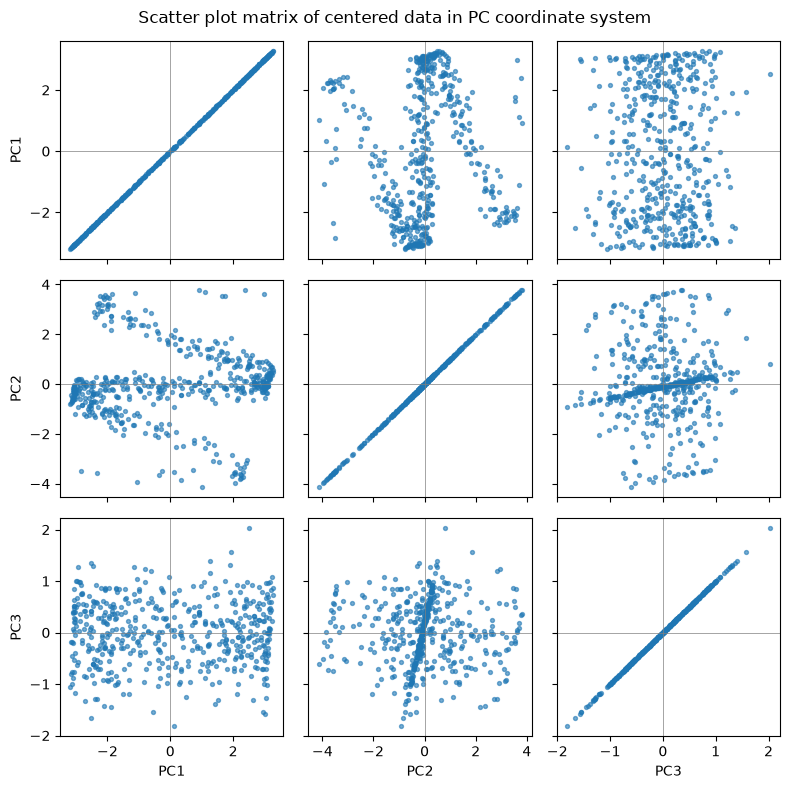

In [30]:
# create scatter plot matrix of centered data in PC coordinate system
fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex="col", sharey="row")
labels = ["PC1", "PC2", "PC3"]

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.scatter(pca_3d_pc_coords[:, j], pca_3d_pc_coords[:, i], s=8, alpha=0.6)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        if i == 2:
            ax.set_xlabel(labels[j])
        if j == 0:
            ax.set_ylabel(labels[i])

fig.suptitle("Scatter plot matrix of centered data in PC coordinate system")
plt.tight_layout()
plt.show()

### Findings
- PCs show no obvious linear correlation with each other -> that is exactly what PCA is designed to achieve: PC1, PC2, and PC3 are orthogonal and have zero covariance
- However, a nonlinear patterns remain, especially in curvy PC1–PC2 and PC2–PC3 -> PCA removed linear dependence (no tilts), but not the nonlinear dependence (e.g., curve, U-shape, ring, bands)

## H1.2c


In [31]:
# select only pc1 coordinates
pc1_coords_3d = pca_3d_pc_coords[:, 0:1]
print(pc1_coords_3d.shape)

# select pc1
pc1_3d = pcs_3d[:, 0:1]
print(pc1_3d.shape)

# reconstruct data points in original feature space via matrix mul
pca_3d_centered_reconstructed_pc1 = pc1_coords_3d @ pc1_3d.T

(500, 1)
(3, 1)


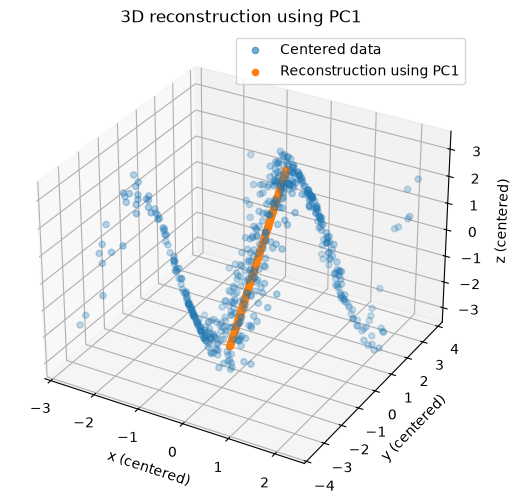

In [32]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pca_3d_centered[:, 0],
    pca_3d_centered[:, 1],
    pca_3d_centered[:, 2],
    alpha=0.6,
    label="Centered data",
)

ax.scatter(
    pca_3d_centered_reconstructed_pc1[:, 0].real,
    pca_3d_centered_reconstructed_pc1[:, 1].real,
    pca_3d_centered_reconstructed_pc1[:, 2].real,
    label="Reconstruction using PC1",
)

ax.set_xlabel("x (centered)")
ax.set_ylabel("y (centered)")
ax.set_zlabel("z (centered)")
ax.set_title("3D reconstruction using PC1")
ax.legend()

plt.show()

In [33]:
# select pc1 and pc2 coordinates
pc1_and_2_coords_3d = pca_3d_pc_coords[:, 0:2]
print(pc1_and_2_coords_3d.shape)

# select pc1 and pc2
pc1_and_2_3d = pcs_3d[:, 0:2]
print(pc1_and_2_3d.shape)

# reconstruct data points in original feature space via matrix mul
pca_3d_centered_reconstructed_pc1_and_2 = pc1_and_2_coords_3d @ pc1_and_2_3d.T

(500, 2)
(3, 2)


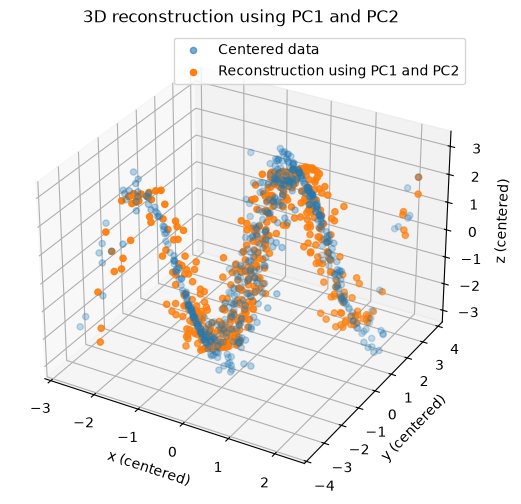

In [34]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pca_3d_centered[:, 0],
    pca_3d_centered[:, 1],
    pca_3d_centered[:, 2],
    alpha=0.6,
    label="Centered data",
)

ax.scatter(
    pca_3d_centered_reconstructed_pc1_and_2[:, 0].real,
    pca_3d_centered_reconstructed_pc1_and_2[:, 1].real,
    pca_3d_centered_reconstructed_pc1_and_2[:, 2].real,
    label="Reconstruction using PC1 and PC2",
)

ax.set_xlabel("x (centered)")
ax.set_ylabel("y (centered)")
ax.set_zlabel("z (centered)")
ax.set_title("3D reconstruction using PC1 and PC2")
ax.legend()

plt.show()

In [35]:
# reconstruct data points in original feature space via matrix mul
print(pca_3d_pc_coords.shape)
print(pcs_3d.shape)
pca_3d_centered_reconstructed_pc_all = pca_3d_pc_coords @ pcs_3d.T

(500, 3)
(3, 3)


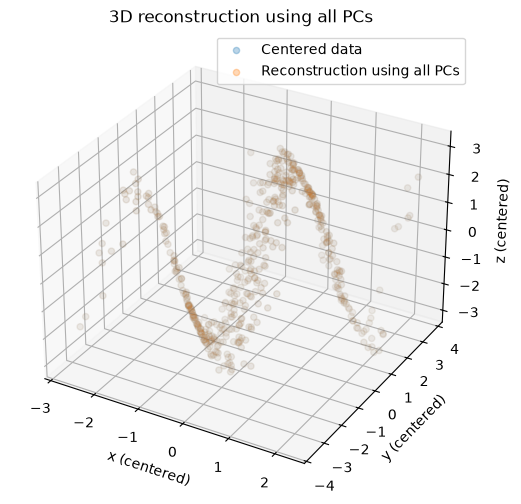

In [36]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pca_3d_centered[:, 0],
    pca_3d_centered[:, 1],
    pca_3d_centered[:, 2],
    alpha=0.3,
    label="Centered data",
)

ax.scatter(
    pca_3d_centered_reconstructed_pc_all[:, 0].real,
    pca_3d_centered_reconstructed_pc_all[:, 1].real,
    pca_3d_centered_reconstructed_pc_all[:, 2].real,
    alpha=0.3,
    label="Reconstruction using all PCs",
)

ax.set_xlabel("x (centered)")
ax.set_ylabel("y (centered)")
ax.set_zlabel("z (centered)")
ax.set_title("3D reconstruction using all PCs")
ax.legend()

plt.show()

### Discussion
- PC1 only: Reconstruction lies on a line, retaining approximately 63.0% of the variance -> losing substantial structure
- PC1 + PC2: Reconstruction lies in a plane, retaining 94.6% of the variance -> good approximation with reduced dimensionality.


# Exercise H1.3: Projections of a dynamical system


## H1.3a


In [37]:
# load data
exp_dat = np.genfromtxt("expDat.txt", delimiter=",", skip_header=1)[
    :, 1:
]  # first col is nan
print(exp_dat.shape)
print(exp_dat)

(100, 20)
[[1. 0. 0. ... 4. 2. 1.]
 [2. 2. 2. ... 1. 1. 2.]
 [3. 2. 3. ... 1. 1. 3.]
 ...
 [1. 3. 2. ... 3. 2. 1.]
 [2. 1. 3. ... 2. 2. 5.]
 [2. 2. 3. ... 0. 3. 1.]]


In [38]:
# center data
mean = np.mean(exp_dat, axis=0)
exp_dat_centered = exp_dat - mean

# calculate covariance matrix
C_dyn = np.cov(exp_dat, rowvar=False)
print("C shape: ", C_dyn.shape)

# determine eigenvalues and eigenvectors
eigenvalues_dyn, eigenvectors_dyn = np.linalg.eig(C_dyn)
print("Eigenvalues shape: ", eigenvalues_dyn.shape)
print("Eigenvectors shape: ", eigenvectors_dyn.shape)  # eigenvectors are stored as cols

C shape:  (20, 20)
Eigenvalues shape:  (20,)
Eigenvectors shape:  (20, 20)


In [39]:
# sort eigenvalues and eigenvectors in descending order (highest to lowest)
idx = np.argsort(eigenvalues_dyn)[::-1]

eigenvalues_dyn = eigenvalues_dyn[idx]
eigenvectors_dyn = eigenvectors_dyn[:, idx]  # leave rows unattached, just change cols

pcs_dyn = eigenvectors_dyn
print(pcs_dyn.shape)

(20, 20)


## H1.3b


In [40]:
# transform into new basis
pca_dyn_pc_coords = exp_dat_centered @ pcs_dyn
pca_dyn_pc_coords.shape

(100, 20)

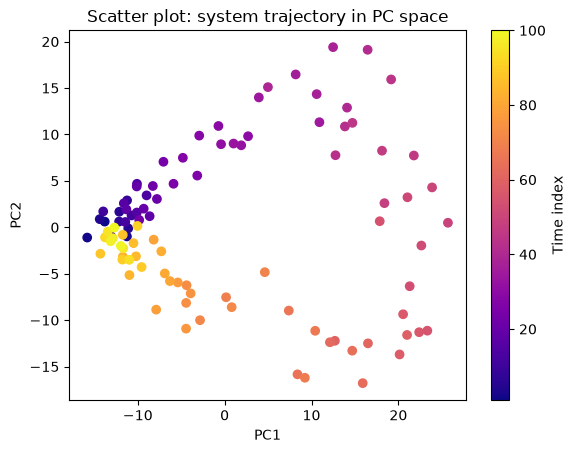

In [41]:
time = np.arange(1, len(pca_dyn_pc_coords) + 1)

plt.scatter(
    pca_dyn_pc_coords[:, 0],
    pca_dyn_pc_coords[:, 1],
    c=time,
    cmap="plasma"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scatter plot: system trajectory in PC space")
plt.colorbar(label="Time index")
plt.show()

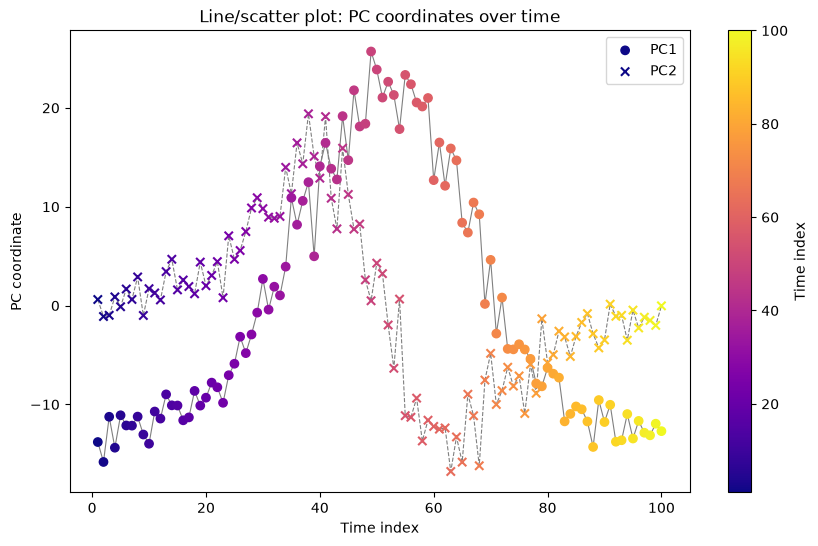

In [42]:
# plot PC1 and PC2 coordinates over time
plt.figure(figsize=(10, 6))

# connect consecutive time points
plt.plot(time, pca_dyn_pc_coords[:, 0].real, color="gray", linewidth=0.8)
plt.plot(
    time, pca_dyn_pc_coords[:, 1].real,
    color="gray", linewidth=0.8, linestyle="--"
)

# use the same time color scale as in the previous scatter plot
plt.scatter(
    time, pca_dyn_pc_coords[:, 0].real,
    c=time, cmap="plasma", marker="o", label="PC1", zorder=3
)
plt.scatter(
    time, pca_dyn_pc_coords[:, 1].real,
    c=time, cmap="plasma", marker="x", label="PC2", zorder=3
)

plt.xlabel("Time index")
plt.ylabel("PC coordinate")
plt.title("Line/scatter plot: PC coordinates over time")
plt.colorbar(label="Time index")
plt.legend()
plt.show()


## H1.3c


In [43]:
# shuffle each feature column independently
rng = np.random.default_rng(42)
exp_dat_centered_shuffled = exp_dat_centered.copy()

for j in range(exp_dat_centered.shape[1]):
    exp_dat_centered_shuffled[:, j] = rng.permutation(exp_dat_centered[:, j])

exp_dat_centered_shuffled.shape

(100, 20)

## H1.3d


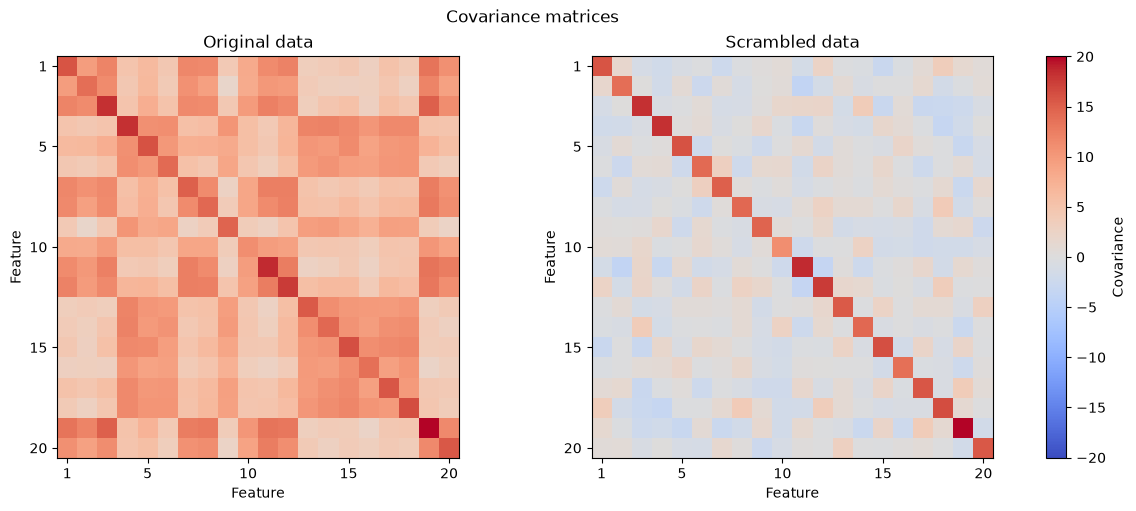

In [44]:
# calculate covariance matrices for original and scrambled centered data
C_dyn_original = np.cov(exp_dat_centered, rowvar=False)
C_dyn_shuffled = np.cov(exp_dat_centered_shuffled, rowvar=False)

# use the same color limits to compare both matrices
color_limit = max(np.abs(C_dyn_original).max(), np.abs(C_dyn_shuffled).max())
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

for ax, C, title in zip(
    axes,
    [C_dyn_original, C_dyn_shuffled],
    ["Original data", "Scrambled data"]
):
    im = ax.imshow(
        C, cmap="coolwarm", vmin=-color_limit, vmax=color_limit,
        extent=(0.5, 20.5, 20.5, 0.5)
    )
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature")
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.set_yticks([1, 5, 10, 15, 20])
    ax.set_title(title)

fig.suptitle("Covariance matrices")
fig.colorbar(im, ax=axes, label="Covariance")
plt.show()


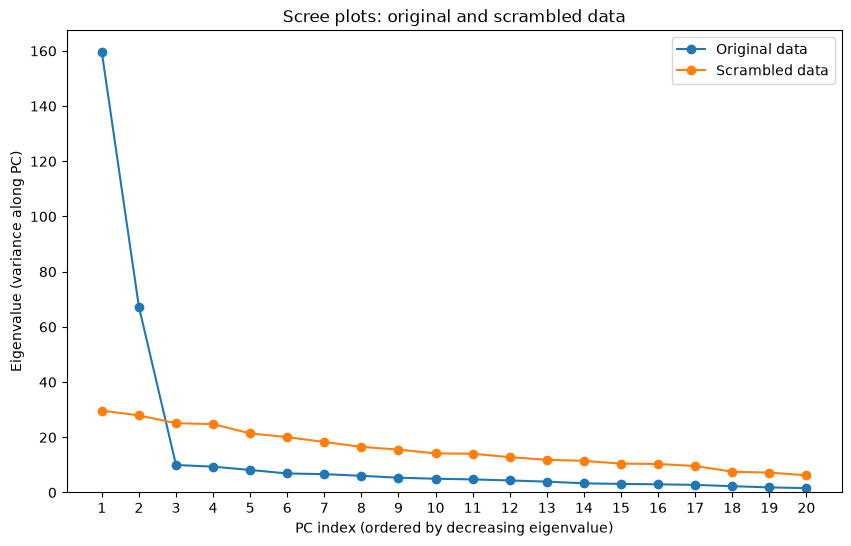

Original: first two PCs explain 71.96% of total variance
Scrambled: first two PCs explain 18.28% of total variance


In [45]:
# eigenvalues of symmetric covariance matrices, sorted from high to low
eigenvalues_dyn_original = np.linalg.eigvalsh(C_dyn_original)[::-1]
eigenvalues_dyn_shuffled = np.linalg.eigvalsh(C_dyn_shuffled)[::-1]
pc_index = np.arange(1, len(eigenvalues_dyn_original) + 1)

plt.figure(figsize=(10, 6))
plt.plot(pc_index, eigenvalues_dyn_original, marker="o", label="Original data")
plt.plot(pc_index, eigenvalues_dyn_shuffled, marker="o", label="Scrambled data")
plt.xlabel("PC index (ordered by decreasing eigenvalue)")
plt.ylabel("Eigenvalue (variance along PC)")
plt.title("Scree plots: original and scrambled data")
plt.xticks(pc_index)
plt.ylim(bottom=0)
plt.legend()
plt.show()

# compare the variance explained by the first two PCs
for label, values in zip(
    ["Original", "Scrambled"],
    [eigenvalues_dyn_original, eigenvalues_dyn_shuffled]
):
    explained = values[:2].sum() / values.sum()
    print(f"{label}: first two PCs explain {explained:.2%} of total variance")


### Interpretation

The original covariance matrix has substantial off-diagonal entries: features vary together. After independently shuffling the columns, these covariances are much closer to zero. They are not exactly zero because there are only 100 samples.

The diagonal entries stay unchanged because shuffling preserves the values and variance of each feature. Consequently, the total variance (the sum of the eigenvalues) also stays unchanged.

The original scree plot has two dominant PCs, explaining about **71.96%** of the total variance. For the scrambled dataset generated with seed 42, the first two PCs explain only **18.28%**. Its variance is spread across more PCs, so a two-PC representation captures much less of the data's variation. Shuffling disrupts the relationships between features that allowed PCA to capture much of the original variation in just two directions. The scrambled eigenvalues need not be equal: feature variances differ and finite-sample covariances remain.
